<a href="https://colab.research.google.com/github/marcyannick1/deeplearning-j4-RNN/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import keras

from keras import layers
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

import time

In [5]:
# TODO : charger le CSV Airline Passengers depuis l'URL jbrownlee/Datasets
# (colonne "Passengers")

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

dataset = df["Passengers"].values

In [6]:
# TODO : convertir en float32, afficher shape et min/max

dataset = dataset.astype("float32")

print("Shape :", dataset.shape)
print("Min :", dataset.min())
print("Max :", dataset.max())

Shape : (144,)
Min : 104.0
Max : 622.0


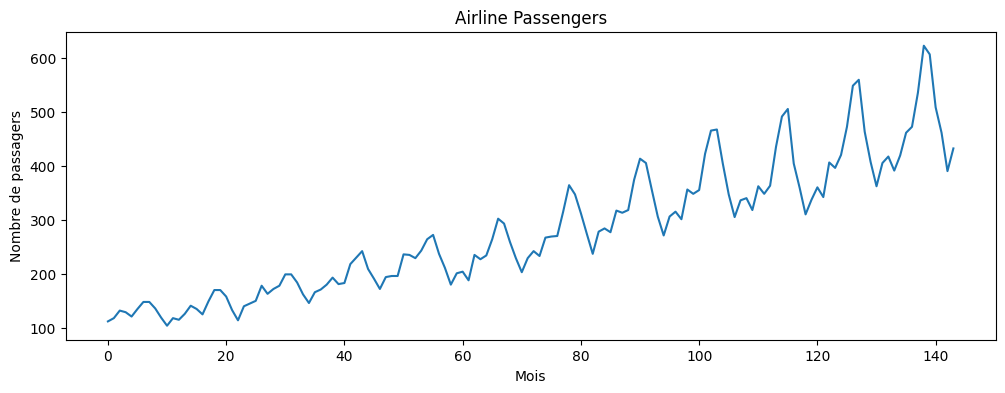

In [7]:
# TODO : afficher rapidement la série temporelle

plt.figure(figsize=(12, 4))
plt.plot(dataset)
plt.title("Airline Passengers")
plt.xlabel("Mois")
plt.ylabel("Nombre de passagers")
plt.show()

In [8]:
# TODO : normaliser avec MinMaxScaler entre 0 et 1
# (le LSTM est sensible aux grandes valeurs)

scaler = MinMaxScaler(feature_range=(0, 1))

dataset = scaler.fit_transform(
    dataset.reshape(-1, 1)
)

In [9]:
# TODO : split temporel 67/33 — jamais de shuffle sur une série temporelle

train_size = int(len(dataset) * 0.67)

train = dataset[:train_size]
test = dataset[train_size:]

In [10]:
def create_dataset(dataset, window_size=12):
    """
    Transforme une série 1D en paires (X, y) via sliding window.

    Retourne :
    X : (N - window_size, window_size, 1)
    y : (N - window_size,)
    """

    X, y = [], []

    for i in range(len(dataset) - window_size):

        # TODO : ajouter la fenêtre de valeurs précédentes dans X
        X.append(dataset[i:i + window_size])

        # TODO : ajouter la valeur suivante comme cible dans y
        y.append(dataset[i + window_size])


    # TODO : convertir X et y en tableaux numpy
    X = np.array(X)
    y = np.array(y)


    return X, y

In [11]:
WINDOW_SIZE = 12

# TODO : créer les datasets train et test avec la fenêtre glissante

X_train, y_train = create_dataset(train, WINDOW_SIZE)

X_test, y_test = create_dataset(test, WINDOW_SIZE)

In [12]:
# TODO : afficher les dimensions finales

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train : (84, 12, 1)
y_train : (84, 1)
X_test : (36, 12, 1)
y_test : (36, 1)


In [13]:
# Construire le modèle : LSTM en régression (return_sequences=False),
# régularisation légère, sortie scalaire continue (pas de sigmoid).

model = keras.Sequential([

    layers.LSTM(
        64,
        input_shape=(WINDOW_SIZE, 1)
    ),

    # TODO : ajouter une couche Dropout (taux modéré, autour de 0.2)

    layers.Dropout(0.2),


    # TODO : ajouter la couche de sortie Dense pour la régression
    # (1 neurone, sans activation)

    layers.Dense(1)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# Compiler le modèle

# TODO : choisir l'optimizer (adam par défaut sur ce type de problème)
# TODO : choisir la loss adaptée à une régression (prédire une valeur continue)
# TODO : ajouter une métrique humaine (MAE garde l'unité passagers)

model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Entraînement

# TODO : choisir epochs (laisser de la marge, EarlyStopping coupera)
# TODO : choisir batch_size (petit dataset, batch petit)
# TODO : ajouter EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


history = model.fit(

    X_train,
    y_train,

    # TODO : epochs=...

    epochs=100,


    # TODO : batch_size=...

    batch_size=8,


    validation_split=0.1,


    # TODO : callbacks=[...]

    callbacks=[early_stop],


    verbose=1,

)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0277 - mae: 0.1359 - val_loss: 0.0347 - val_mae: 0.1596
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0073 - mae: 0.0713 - val_loss: 0.0109 - val_mae: 0.0858
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0053 - mae: 0.0602 - val_loss: 0.0289 - val_mae: 0.1429
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0047 - mae: 0.0540 - val_loss: 0.0197 - val_mae: 0.1120
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0049 - mae: 0.0561 - val_loss: 0.0133 - val_mae: 0.0971
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0045 - mae: 0.0540 - val_loss: 0.0137 - val_mae: 0.0991
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0046 - mae: 0.0532 - val_loss: 0.0168 - val_mae: 0.1068
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0035 - mae: 0.0454 - val_loss: 0.0114 - val_mae: 0.0883
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - lo

In [16]:
# TODO : prédire sur X_train et X_test

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [17]:
# TODO : dénormaliser les prédictions et les valeurs réelles
# (scaler.inverse_transform)

y_train_real = scaler.inverse_transform(y_train)

y_test_real = scaler.inverse_transform(y_test)

y_train_pred_real = scaler.inverse_transform(y_train_pred)

y_test_pred_real = scaler.inverse_transform(y_test_pred)

In [18]:
# TODO : calculer RMSE train et RMSE test,
# les afficher en unité passagers

rmse_train = np.sqrt(
    mean_squared_error(
        y_train_real,
        y_train_pred_real
    )
)


rmse_test = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_test_pred_real
    )
)


print(f"RMSE train : {rmse_train:.2f} passagers")

print(f"RMSE test : {rmse_test:.2f} passagers")

RMSE train : 43.80 passagers
RMSE test : 77.35 passagers


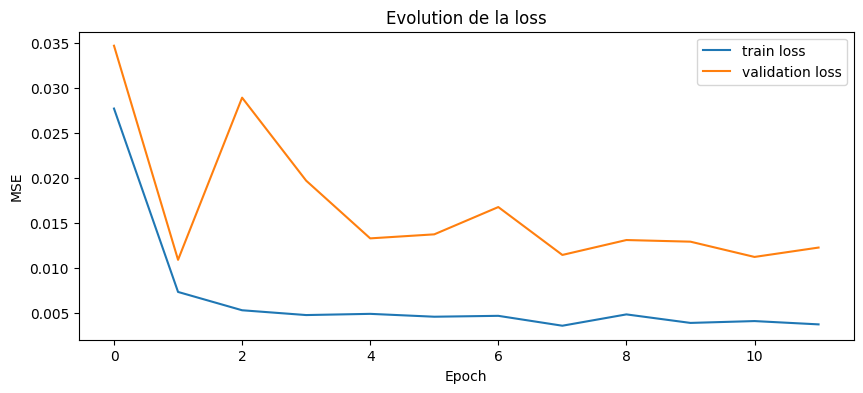

In [19]:
# TODO : tracer loss train vs val loss

plt.figure(figsize=(10,4))

plt.plot(
    history.history["loss"],
    label="train loss"
)

plt.plot(
    history.history["val_loss"],
    label="validation loss"
)

plt.title("Evolution de la loss")

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.legend()

plt.show()

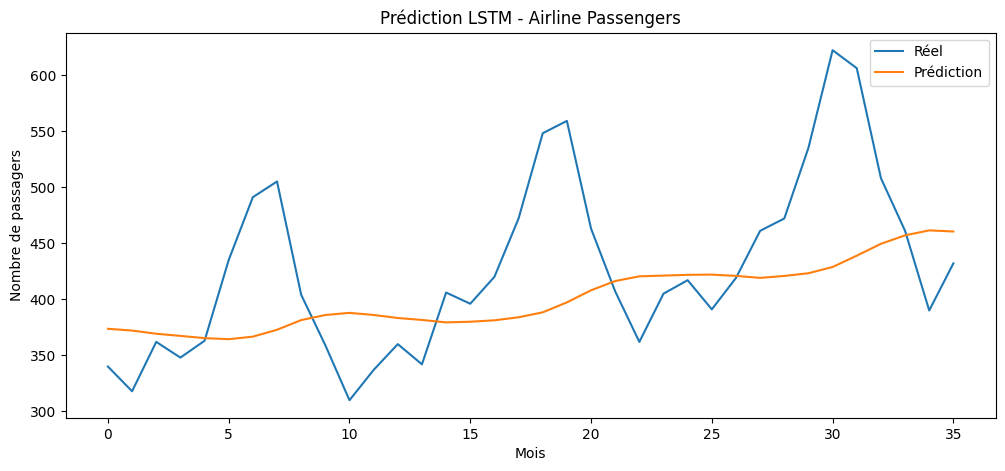

In [20]:
# TODO : tracer prédictions vs ground truth sur la série complète
plt.figure(figsize=(12,5))


plt.plot(
    y_test_real,
    label="Réel"
)


plt.plot(
    y_test_pred_real,
    label="Prédiction"
)


plt.title("Prédiction LSTM - Airline Passengers")

plt.xlabel("Mois")

plt.ylabel("Nombre de passagers")

plt.legend()

plt.show()

In [21]:
def build_and_train(rnn_layer_class, units=64, epochs=50, label=''):
    """
    Construit et entraîne un modèle avec le layer RNN passé en paramètre.
    Retourne :
    (modèle entraîné, historique, durée en secondes, RMSE test)
    """

    # TODO : construire le Sequential
    # (rnn_layer_class + Dropout + Dense)

    model = keras.Sequential([

        rnn_layer_class(
            units,
            input_shape=(WINDOW_SIZE, 1)
        ),

        layers.Dropout(0.2),

        layers.Dense(1)

    ])


    # TODO : compiler (adam, mse, mae)

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )


    # TODO : mesurer la durée d'entraînement (time.time())

    start_time = time.time()


    # TODO : entraîner avec EarlyStopping(patience=10)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )


    history = model.fit(
        X_train,
        y_train,

        epochs=epochs,

        batch_size=8,

        validation_split=0.1,

        callbacks=[early_stop],

        verbose=0
    )


    end_time = time.time()

    training_time = end_time - start_time



    # TODO : calculer le RMSE test
    # (dénormaliser les prédictions)

    y_pred = model.predict(
        X_test,
        verbose=0
    )


    y_pred_real = scaler.inverse_transform(y_pred)

    y_test_real = scaler.inverse_transform(y_test)


    rmse = np.sqrt(
        mean_squared_error(
            y_test_real,
            y_pred_real
        )
    )


    # Informations entraînement

    epochs_real = len(history.history["loss"])

    duration_per_epoch = training_time / epochs_real

    final_val_loss = history.history["val_loss"][-1]


    print("=" * 50)

    print(f"Modèle : {label}")

    print(f"Paramètres : {model.count_params()}")

    print(f"Epochs réelles : {epochs_real}")

    print(f"Durée totale : {training_time:.2f} secondes")

    print(f"Durée / epoch : {duration_per_epoch:.4f} secondes")

    print(f"Val loss finale : {final_val_loss:.6f}")

    print(f"RMSE test : {rmse:.2f} passagers")


    return model, history, training_time, rmse

In [22]:
# Entraînement LSTM

lstm_model, lstm_history, lstm_time, lstm_rmse = build_and_train(
    layers.LSTM,
    units=64,
    epochs=50,
    label="LSTM"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modèle : LSTM
Paramètres : 16961
Epochs réelles : 50
Durée totale : 7.87 secondes
Durée / epoch : 0.1573 secondes
Val loss finale : 0.006051
RMSE test : 44.03 passagers


In [23]:
# Entraînement GRU

gru_model, gru_history, gru_time, gru_rmse = build_and_train(
    layers.GRU,
    units=64,
    epochs=50,
    label="GRU"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modèle : GRU
Paramètres : 12929
Epochs réelles : 50
Durée totale : 8.96 secondes
Durée / epoch : 0.1793 secondes
Val loss finale : 0.004803
RMSE test : 48.86 passagers
